## Composite analysis for model output

### Import package

In [1]:
import h5py
import numpy as np
from scipy.integrate import cumulative_trapezoid

from typing import cast, Dict
from pathlib import Path

from matplotlib import pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import TwoSlopeNorm

### Composite for NoRad experiment

#### Load NoRad experiments

In [2]:
# input directory
input_dir: Path = Path("/work/b11209013/Kuang2008_v0.5.0/full")

# ignore the first n (default: 20 days) for composite
skip_days: np.intp = np.intp(20)

# load NoRad data
with h5py.File(input_dir / "NoRad/GalerkinState.h5", "r") as norad_ds:

    # coordinates
    coords: Dict[str, np.ndarray] = {
        key: cast(h5py.Dataset, norad_ds[key])[...]
        for key in ["x", "z"]
    }

    norad_variables: Dict[str, np.ndarray] = {
        key: cast(h5py.Dataset, norad_ds[key])[..., skip_days:, :]
        for key in ["J1", "J2", "w1", "w2", "T1", "T2"]
    } # shape: (nz, nx, nt, nens)

NZ, NX, NT, NENS = norad_variables["J1"].shape

#### Add the first and second mode

In [3]:
norad_field: Dict[str, np.ndarray] = {
    key: norad_variables[f"{key}1"] + norad_variables[f"{key}2"]
    for key in ["J", "w", "T"]
}

del norad_variables

#### Calculate potential temperature

##### Constructing background information

In [4]:
# construct background profiles
Γ_d  : float      = 9.81 / 1004.5
Γ    : float      = 0.0065
T_bar: np.ndarray = 300 - Γ * coords["z"]
p_bar: np.ndarray = 1e5 * (1 - Γ*coords["z"]/300) ** (9.81 / 287.5 / Γ)

##### Functions for potential temperature and DCIN

Calculate full temperature and hydrostatic pressure at each height before compositing. Pressure is anchored at 1000 hPa at the surface (z = 0). Potential temperature uses $\theta=T(p_0/p)^{R_d/c_p}$ ([reference](https://unidata.github.io/MetPy/latest/api/generated/metpy.calc.potential_temperature.html)).

Retain the model DCIN definition: the arithmetic mean of full potential temperature over 750–800 hPa minus its mean over 800–1000 hPa, in K. Select levels using background pressure in Pa. Calculate DCIN before centering with the same heating-based shifts and averaging over time and ensembles.

In [5]:
def _calc_potential_temperature(
        data: np.ndarray,
        pressure: np.ndarray,
) -> np.ndarray:
    return data * (1e5 / pressure) ** (287.5 / 1004.5)


def _calc_hydrostatic_pressure(
        temperature: np.ndarray,
        height: np.ndarray,
) -> np.ndarray:
    # Integrate from the surface to each height, retaining the vertical axis.
    integral = cumulative_trapezoid(1 / temperature, x=height, axis=0, initial=0)
    return 1e5 * np.exp(-9.81 / 287.5 * integral)


def _calc_dcin(
        theta_tot: np.ndarray,
        background_pressure: np.ndarray,
) -> np.ndarray:
    # Background pressure is in Pa; these bounds correspond to hPa * 100.
    top_layer = (background_pressure >= 75000.0) & (background_pressure <= 80000.0)
    boundary_layer = (background_pressure >= 80000.0) & (background_pressure <= 100000.0)
    if not np.any(top_layer) or not np.any(boundary_layer):
        raise ValueError("DCIN requires levels in both the 750–800 and 800–1000 hPa layers.")
    return (np.mean(theta_tot[top_layer], axis=0)
            - np.mean(theta_tot[boundary_layer], axis=0))


norad_T_tot: np.ndarray = T_bar[:, None, None, None] + norad_field["T"]
norad_p_tot: np.ndarray = _calc_hydrostatic_pressure(norad_T_tot, coords["z"])

norad_field["theta_tot"] = _calc_potential_temperature(norad_T_tot, norad_p_tot)
norad_field["theta"] = norad_field["theta_tot"] - np.nanmean(
    norad_field["theta_tot"], axis=(1, 2), keepdims=True,
)
norad_field["DCIN"] = _calc_dcin(norad_field["theta_tot"], p_bar)

#### Calculate covariance between convective heating and temperature perturbations

In [6]:
norad_field["source"] = norad_field["J"] * norad_field["T"] / T_bar[:, None, None, None] * (Γ_d) / (Γ_d - Γ)

#### Centering profiles for different variables

In [7]:
# defining the center
x_half: np.intp = np.intp(NX//2)

# use vertically averaged convective heating as 
# a proxy of convection parameterization
J_vavg: np.ndarray = np.nanmean(norad_field["J"], axis=0)

# find maximum of the vertically averaged convective heating
# and calculate shifting
J_vavg_max: np.ndarray = np.nanargmax(J_vavg, axis=0)

# calculate shifts
shifts: np.ndarray = x_half - J_vavg_max

# roll maximum to the center
def _multi_axis_rolling(
        data  : np.ndarray,
        shifts: np.ndarray,
) -> np.ndarray:
    # Accept (z, x, time, ensemble) fields and (x, time, ensemble) DCIN.
    nt, nens = shifts.shape

    # rolling along time and ensemble axis
    tmp_all_rolling: list = []

    for j in range(nt):
        tmp_ens_rolling: list = [] 

        for i in range(nens):
            tmp_ens_rolling.append(
                np.roll(
                    data[..., j, i],
                    shift = shifts[j, i],
                    axis=-1
                )
            )

        tmp_all_rolling.append(np.array(tmp_ens_rolling))

    return np.array(tmp_all_rolling)

norad_rolled_field: Dict[str, np.ndarray] = {
    key: _multi_axis_rolling(value, shifts=shifts)
    for (key,value) in norad_field.items()
}

# mean over time and ensembles
norad_composite: Dict[str, np.ndarray] = {
    key: np.nanmean(values, axis=(0, 1))
    for (key, values) in norad_rolled_field.items()
}

#### Visualizing the composite profiles

##### Setup coordinates

In [8]:
# Shared style, matching the ERA5 composite notebook.
FIGURE_DIR = Path("/home/b11209013/Manuscript_Prep/KW_CRI/Figure/model_composite")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
NORAD_DIR = FIGURE_DIR / "NoRad"
NORAD_DIR.mkdir(parents=True, exist_ok=True)

LONGITUDE_LIMIT = 50.0

# The rolling step places the convective center at NX // 2.
metres_per_degree = 2 * np.pi * 6.371e6 / 360.0
x_rel = (coords["x"] - coords["x"][NX // 2]) / metres_per_degree
height_km = coords["z"] / 1000.0
visible = np.abs(x_rel) <= LONGITUDE_LIMIT

##### assisting functions

In [9]:
def _remove_zero_contour(
        data: np.ndarray
) -> np.ndarray:

    total_level = MaxNLocator(nbins=8).tick_values(
        np.nanmin(data), np.nanmax(data),
        )

    total_level = np.asarray(
        MaxNLocator(nbins=8).tick_values(
            np.nanmin(data),
            np.nanmax(data),
        ),
        dtype=float,
    )
    return total_level[~np.isclose(total_level, 0.0)]

##### Visualize w vs. J profiles

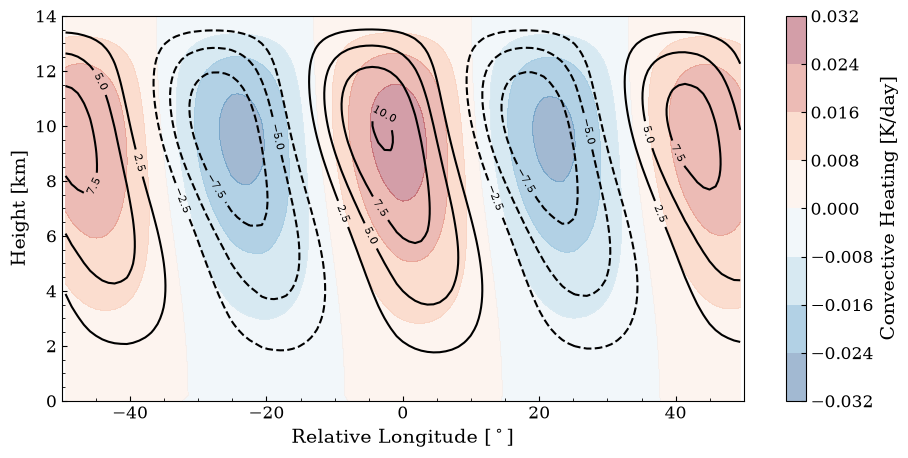

In [10]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "legend.fontsize": 12,
    "figure.titlesize": 18,
    "contour.negative_linestyle": "dashed",
})

fig, ax = plt.subplots(1, 1, figsize=(11, 5))

J_ctf = ax.contourf(
    x_rel[visible], height_km, norad_composite["J"][:, visible],
    cmap="RdBu_r", norm=TwoSlopeNorm(0.0), alpha=0.4,
)
# Keep automatically spaced contour levels, excluding zero.
w_ct = ax.contour(
    x_rel[visible], height_km, norad_composite["w"][:, visible],
    levels=_remove_zero_contour(norad_composite["w"][:, visible]),
    colors="k"
)
ax.minorticks_on()
ax.tick_params(direction="in")
ax.set_xlim(-50, 50)
ax.set_xlabel(r"Relative Longitude [$^\circ$]")
ax.set_ylabel("Height [km]")
plt.colorbar(J_ctf, ax=ax, label="Convective Heating [K/day]")
plt.clabel(w_ct, inline=True, fontsize=8)
plt.savefig(NORAD_DIR / "wJ_composite.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

##### Visualizing T vs. J with DCIN

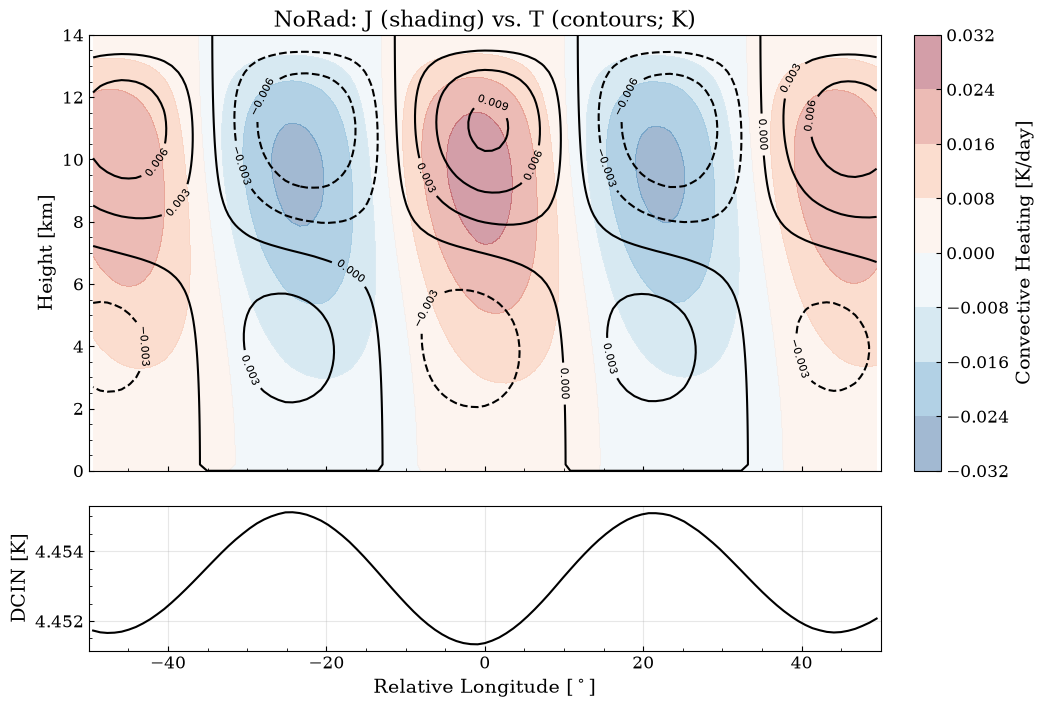

In [11]:
fig = plt.figure(figsize=(11, 8))
# A separate colorbar column keeps both longitude axes aligned.
grid = fig.add_gridspec(
    2, 2, height_ratios=[3, 1], width_ratios=[1, 0.035],
    hspace=0.12, wspace=0.08,
)
ax = fig.add_subplot(grid[0, 0])
dcin_ax = fig.add_subplot(grid[1, 0], sharex=ax)
cbar_ax = fig.add_subplot(grid[0, 1])

J_ctf = ax.contourf(
    x_rel[visible], height_km, norad_composite["J"][:, visible],
    cmap="RdBu_r", norm=TwoSlopeNorm(0.0), alpha=0.4,
)
T_ct = ax.contour(
    x_rel[visible], height_km, norad_composite["T"][:, visible],
    levels=6, colors="k",
)
ax.minorticks_on()
ax.tick_params(direction="in", labelbottom=False)
ax.set_xlim(-LONGITUDE_LIMIT, LONGITUDE_LIMIT)
ax.set_ylabel("Height [km]")
ax.set_title("NoRad: J (shading) vs. T (contours; K)")
fig.colorbar(J_ctf, cax=cbar_ax, label="Convective Heating [K/day]")
ax.clabel(T_ct, inline=True, fontsize=8)

# DCIN retains the full-field layer difference, with the same convective center.
dcin_ax.plot(
    x_rel[visible], norad_composite["DCIN"][visible],
    color="k", linewidth=1.5,
)
dcin_ax.minorticks_on()
dcin_ax.tick_params(direction="in")
dcin_ax.set_xlabel(r"Relative Longitude [$^\circ$]")
dcin_ax.set_ylabel("DCIN [K]")
dcin_ax.grid(alpha=0.3)

fig.savefig(NORAD_DIR / "TJ_composite.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

##### Visualizing EAPE generation

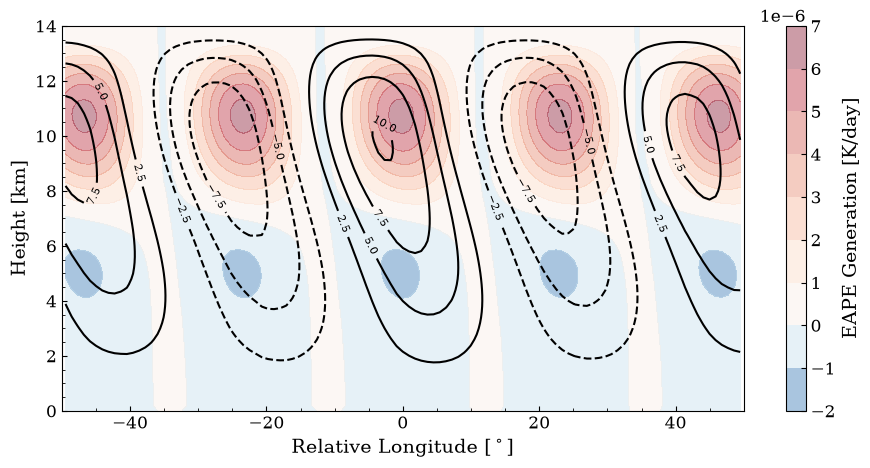

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(11, 5))

J_ctf = ax.contourf(
    x_rel[visible], height_km, norad_composite["source"][:, visible],
    cmap="RdBu_r", norm=TwoSlopeNorm(0.0), alpha=0.4,
)
# Keep automatically spaced contour levels, excluding zero.
w_ct = ax.contour(
    x_rel[visible], height_km, norad_composite["w"][:, visible],
    levels=_remove_zero_contour(norad_composite["w"][:, visible]),
    colors="k"
)
ax.minorticks_on()
ax.tick_params(direction="in")
ax.set_xlim(-50, 50)
ax.set_xlabel(r"Relative Longitude [$^\circ$]")
ax.set_ylabel("Height [km]")
plt.colorbar(J_ctf, ax=ax, label="EAPE Generation [K/day]")
plt.clabel(w_ct, inline=True, fontsize=8)
plt.savefig(NORAD_DIR / "EAPE_gen_composite.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

### Composite for CldRad experiment

#### Load CldRad experiments

In [13]:
# load CldRad data
with h5py.File(input_dir / "CldRad/GalerkinState.h5", "r") as cldrad_ds:

    # coordinates
    cldrad_coords: Dict[str, np.ndarray] = {
        key: cast(h5py.Dataset, cldrad_ds[key])[...]
        for key in ["x", "z"]
    }

    cldrad_variables: Dict[str, np.ndarray] = {
        key: cast(h5py.Dataset, cldrad_ds[key])[..., skip_days:, :]
        for key in ["J1", "J2", "w1", "w2", "T1", "T2"]
    } # shape: (nz, nx, nt, nens)

CLDRAD_NZ, CLDRAD_NX, CLDRAD_NT, CLDRAD_NENS = cldrad_variables["J1"].shape

#### Add the first and second mode

In [14]:
cldrad_field: Dict[str, np.ndarray] = {
    key: cldrad_variables[f"{key}1"] + cldrad_variables[f"{key}2"]
    for key in ["J", "w", "T"]
}

del cldrad_variables

#### Calculate potential temperature and DCIN

In [15]:
# Use this experiment's vertical grid and the same thermodynamic calculations.
cldrad_T_bar: np.ndarray = 300 - Γ * cldrad_coords["z"]
cldrad_p_bar: np.ndarray = 1e5 * (1 - Γ * cldrad_coords["z"] / 300) ** (9.81 / 287.5 / Γ)
cldrad_T_tot: np.ndarray = cldrad_T_bar[:, None, None, None] + cldrad_field["T"]
cldrad_p_tot: np.ndarray = _calc_hydrostatic_pressure(cldrad_T_tot, cldrad_coords["z"])

cldrad_field["theta_tot"] = _calc_potential_temperature(cldrad_T_tot, cldrad_p_tot)
cldrad_field["theta"] = cldrad_field["theta_tot"] - np.nanmean(
    cldrad_field["theta_tot"], axis=(1, 2), keepdims=True,
)
cldrad_field["DCIN"] = _calc_dcin(cldrad_field["theta_tot"], cldrad_p_bar)

#### Calculate covariance between convective heating and temperature perturbations

In [16]:
cldrad_field["source"] = cldrad_field["J"] * cldrad_field["T"] / cldrad_T_bar[:, None, None, None] * (Γ_d) / (Γ_d - Γ)

#### Centering profiles for different variables

In [17]:
# defining the center
cldrad_x_half: np.intp = np.intp(CLDRAD_NX//2)

# use vertically averaged convective heating as 
# a proxy of convection parameterization
cldrad_J_vavg: np.ndarray = np.nanmean(cldrad_field["J"], axis=0)

# find maximum of the vertically averaged convective heating
# and calculate shifting
cldrad_J_vavg_max: np.ndarray = np.nanargmax(cldrad_J_vavg, axis=0)

# calculate shifts
cldrad_shifts: np.ndarray = cldrad_x_half - cldrad_J_vavg_max

# Use the same rolling helper as the NoRad composite.
cldrad_rolled_field: Dict[str, np.ndarray] = {
    key: _multi_axis_rolling(value, shifts=cldrad_shifts)
    for (key,value) in cldrad_field.items()
}

# mean over time and ensembles
cldrad_composite: Dict[str, np.ndarray] = {
    key: np.nanmean(values, axis=(0, 1))
    for (key, values) in cldrad_rolled_field.items()
}

#### Visualizing the composite profiles

##### Setup coordinates

In [18]:
CLDRAD_DIR = FIGURE_DIR / "CldRad"
CLDRAD_DIR.mkdir(parents=True, exist_ok=True)

# The rolling step places the convective center at CLDRAD_NX // 2.
cldrad_x_rel = (cldrad_coords["x"] - cldrad_coords["x"][CLDRAD_NX // 2]) / metres_per_degree
cldrad_height_km = cldrad_coords["z"] / 1000.0
cldrad_visible = np.abs(cldrad_x_rel) <= LONGITUDE_LIMIT

##### Visualize w vs. J profiles

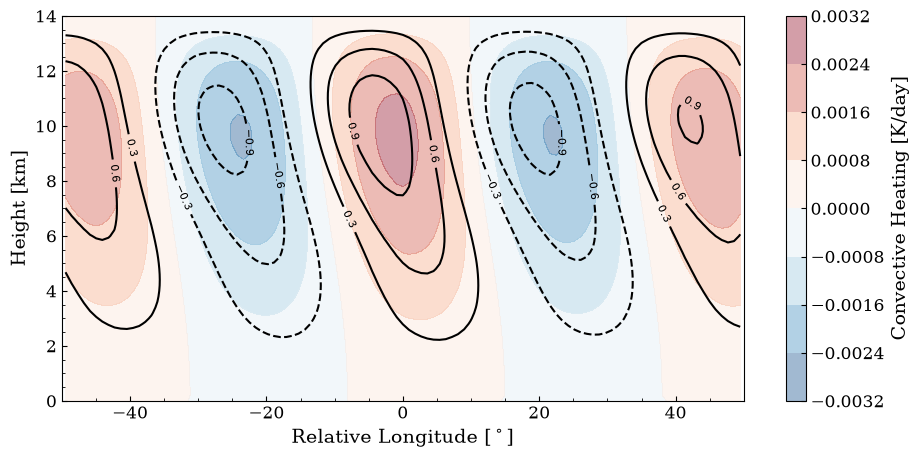

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(11, 5))

J_ctf = ax.contourf(
    cldrad_x_rel[cldrad_visible], cldrad_height_km, cldrad_composite["J"][:, cldrad_visible],
    cmap="RdBu_r", norm=TwoSlopeNorm(0.0), alpha=0.4,
)
# Keep automatically spaced contour levels, excluding zero.
w_ct = ax.contour(
    cldrad_x_rel[cldrad_visible], cldrad_height_km, cldrad_composite["w"][:, cldrad_visible],
    levels=_remove_zero_contour(cldrad_composite["w"][:, cldrad_visible]),
    colors="k"
)
ax.minorticks_on()
ax.tick_params(direction="in")
ax.set_xlim(-50, 50)
ax.set_xlabel(r"Relative Longitude [$^\circ$]")
ax.set_ylabel("Height [km]")
plt.colorbar(J_ctf, ax=ax, label="Convective Heating [K/day]")
plt.clabel(w_ct, inline=True, fontsize=8)
plt.savefig(CLDRAD_DIR / "wJ_composite.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

##### Visualizing T vs. J with DCIN

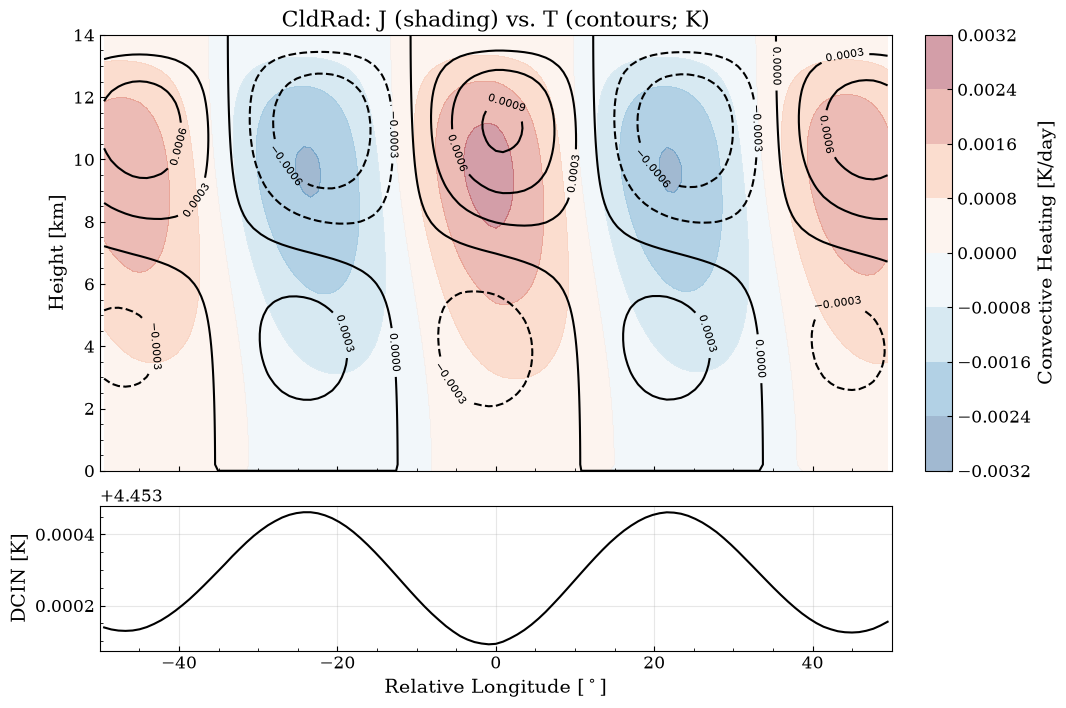

In [20]:
fig = plt.figure(figsize=(11, 8))
# A separate colorbar column keeps both longitude axes aligned.
grid = fig.add_gridspec(
    2, 2, height_ratios=[3, 1], width_ratios=[1, 0.035],
    hspace=0.12, wspace=0.08,
)
ax = fig.add_subplot(grid[0, 0])
dcin_ax = fig.add_subplot(grid[1, 0], sharex=ax)
cbar_ax = fig.add_subplot(grid[0, 1])

J_ctf = ax.contourf(
    cldrad_x_rel[cldrad_visible], cldrad_height_km, cldrad_composite["J"][:, cldrad_visible],
    cmap="RdBu_r", norm=TwoSlopeNorm(0.0), alpha=0.4,
)
T_ct = ax.contour(
    cldrad_x_rel[cldrad_visible], cldrad_height_km, cldrad_composite["T"][:, cldrad_visible],
    levels=6, colors="k",
)
ax.minorticks_on()
ax.tick_params(direction="in", labelbottom=False)
ax.set_xlim(-LONGITUDE_LIMIT, LONGITUDE_LIMIT)
ax.set_ylabel("Height [km]")
ax.set_title("CldRad: J (shading) vs. T (contours; K)")
fig.colorbar(J_ctf, cax=cbar_ax, label="Convective Heating [K/day]")
ax.clabel(T_ct, inline=True, fontsize=8)

# DCIN retains the full-field layer difference, with the same convective center.
dcin_ax.plot(
    cldrad_x_rel[cldrad_visible], cldrad_composite["DCIN"][cldrad_visible],
    color="k", linewidth=1.5,
)
dcin_ax.minorticks_on()
dcin_ax.tick_params(direction="in")
dcin_ax.set_xlabel(r"Relative Longitude [$^\circ$]")
dcin_ax.set_ylabel("DCIN [K]")
dcin_ax.grid(alpha=0.3)

fig.savefig(CLDRAD_DIR / "TJ_composite.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

##### Visualizing EAPE generation

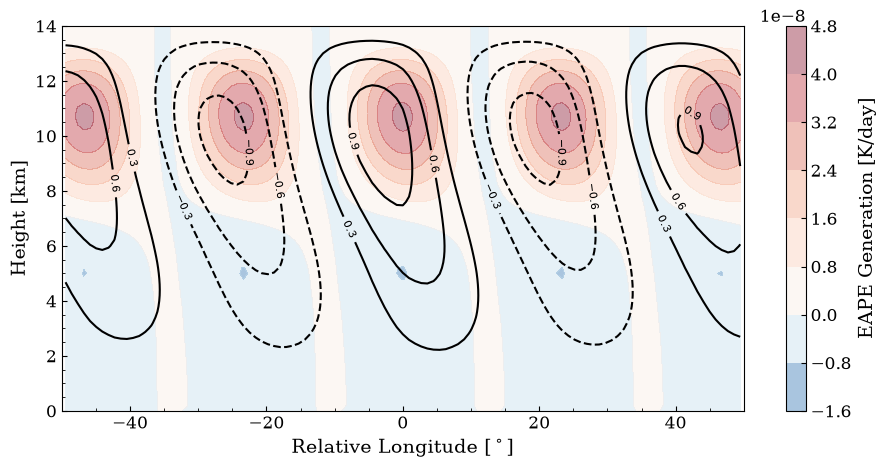

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(11, 5))

J_ctf = ax.contourf(
    x_rel[visible], height_km, cldrad_composite["source"][:, visible],
    cmap="RdBu_r", norm=TwoSlopeNorm(0.0), alpha=0.4,
)
# Keep automatically spaced contour levels, excluding zero.
w_ct = ax.contour(
    x_rel[visible], height_km, cldrad_composite["w"][:, visible],
    levels=_remove_zero_contour(cldrad_composite["w"][:, visible]),
    colors="k"
)
ax.minorticks_on()
ax.tick_params(direction="in")
ax.set_xlim(-50, 50)
ax.set_xlabel(r"Relative Longitude [$^\circ$]")
ax.set_ylabel("Height [km]")
plt.colorbar(J_ctf, ax=ax, label="EAPE Generation [K/day]")
plt.clabel(w_ct, inline=True, fontsize=8)
plt.savefig(CLDRAD_DIR / "EAPE_gen_composite.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)